In [1]:
import numpy as np
import pandas as pd
import geopandas as gp

from mgwr.gwr import GWR as OfficialGWR

from src.log.gwr_logger import GwrLogger
from src.kernel.gwr_kernel import GwrKernel
from src.model.gwr import GWR
from src.dataset.interfaces.idataset import FieldInfo
from src.dataset.spatial_dataset import SpatialDataset

Create the Georgia dataset

SpatialDataset : Data schema is verified.


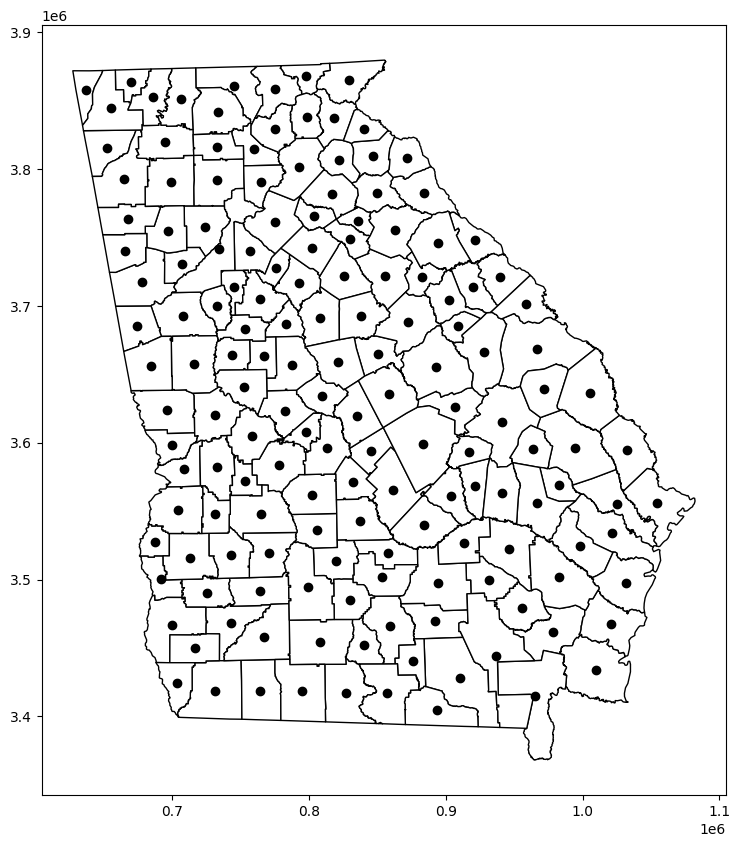

In [4]:
georgia_data = pd.read_csv(r'../../../data/GData_utm.csv')
georgia_geometry = gp.read_file(r'../../../data/G_utm.shp')
dataset = SpatialDataset(
    georgia_data,
    FieldInfo(
        predictor_fields=['PctFB', 'PctBlack', 'PctRural'],
        response_field='PctBach',
        coordinate_x_field='X',
        coordinate_y_field='Y'
    ),
    isSpherical=False,
    geometry=georgia_geometry
)
dataset.plot_map()

Create the GWR model (lmgwr codebase)

In [5]:

manual_bandwidth = 100

# Create a GWR kernel and GWR model.
kernel = GwrKernel(dataset, 'bisquare')
refactored_gwr = GWR(dataset, kernel)

GWR : GWR model is initialized.


Create the GWR model (Official MGWR codebase)

In [6]:
g_X = dataset.X[:, 1:]
g_y = dataset.y.reshape(-1, 1)
g_coords = dataset.coordinates.tolist()
official_gwr = OfficialGWR(g_coords, g_y, g_X, manual_bandwidth)

Fit both models with the same bandwidth

In [7]:
refactored_gwr.update_bandwidth(manual_bandwidth).fit()
official_gwr_result = official_gwr.fit()

In [8]:
print(f"{'Custom GWR R-squared:':30} {refactored_gwr.r_squared:10.4f}")
print(f"{'Official MGWR GWR R-squared:':30} {official_gwr_result.R2:10.4f}")

print(f"{'Custom GWR AIC:':30} {refactored_gwr.aic:10.2f}")
print(f"{'Custom GWR AICc:':30} {refactored_gwr.aicc:10.2f}")
print(f"{'Official MGWR GWR AIC:':30} {official_gwr_result.aic:10.2f}")
print(f"{'Official MGWR GWR AICc:':30} {official_gwr_result.aicc:10.2f}")

# Compare coefficient matrices
betas_match = np.allclose(refactored_gwr.betas, official_gwr_result.params)
print(f"{'Do coefficient matrices match?':30} {'Yes' if betas_match else 'No':>10}")


Custom GWR R-squared:              0.6866
Official MGWR GWR R-squared:       0.6866
Custom GWR AIC:                    296.69
Custom GWR AICc:                   300.04
Official MGWR GWR AIC:             296.69
Official MGWR GWR AICc:            300.04
Do coefficient matrices match?        Yes
